# Scalability Benchmark: ECLYPSE vs. ECLYPSE+NET

This section evaluates the computational overhead introduced by the network extension compared to the base ECLYPSE framework. To ensure a fair and consistent comparison, the benchmark tests identical Fat-Tree topologies of increasing sizes ($k \in \{4, 6, 8, 10, 12\}$) across both simulation engines.

Starting Scalability Benchmark with Fat-Tree Topologies...
Testing Fat-Tree with k=4...
16:39:34.735 | INFO | SimulationConfig - Target path exists; writing to /home/davide/eclypse-sim-20260715_163934 instead
Testing Fat-Tree with k=6...
Testing Fat-Tree with k=8...
Testing Fat-Tree with k=10...
Testing Fat-Tree with k=12...


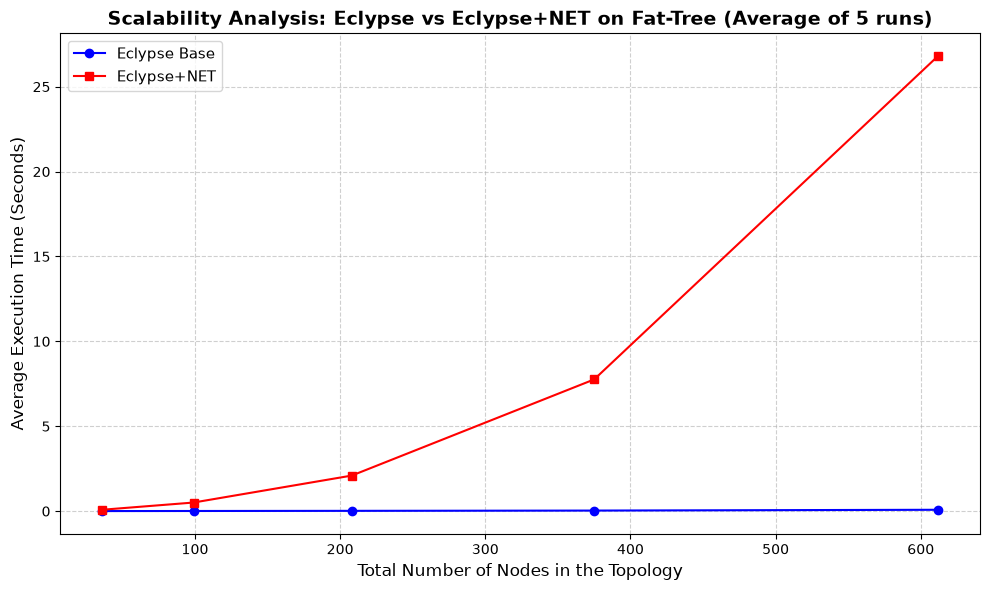

   k_param  Total_Nodes  Eclypse Base (s)  Eclypse+NET (s)
0        4           36          0.005763         0.082513
1        6           99          0.010433         0.508093
2        8          208          0.018829         2.096138
3       10          375          0.035032         7.759473
4       12          612          0.082035        26.815931


In [1]:
import time
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt

GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Import of the base Eclypse modules
from eclypse.graph import Infrastructure
from eclypse.graph import Application
from eclypse.simulation import Simulation, SimulationConfig
from eclypse.placement.strategies import StaticStrategy

# Import of the Eclypse+NET modules
from eclypse.network import Network, NetworkApplication, PacketGenerationEvent, RoutingEvent

# Import the topology generator
from eclypse.builders.infrastructure.generators import get_fat_tree


def run_eclypse_base_shared(base_infra: Infrastructure, steps: int = 10) -> float:
    """Execute the base simulation using a pre-generated shared topology.

    Args:
        base_infra: The shared infrastructure graph.
        steps: The maximum number of simulation steps.

    Returns:
        The execution time of the simulation in seconds.
    """
    num_nodes = len(base_infra.nodes)
    app = Application(f"Base_App_{num_nodes}")
    mapping = {}

    # Parse the infrastructure to set resources and map application nodes
    for node in base_infra.nodes():
        base_infra.nodes[node]['cpu'] = 2
        base_infra.nodes[node]['ram'] = 4

        # Deploy an application component on nodes designated as hosts
        if "host" in node:
            app_name = f"App_{node}"
            app.add_node(app_name, cpu=1, ram=1)
            mapping[app_name] = node

    config = SimulationConfig(
        seed=GLOBAL_SEED,
        max_steps=steps,
        include_default_metrics=False,
        log_level="ERROR"
    )

    sim = Simulation(base_infra, simulation_config=config)
    sim.register(app, placement_strategy=StaticStrategy(mapping))

    start_time = time.perf_counter()
    sim.start()
    sim.wait()
    return time.perf_counter() - start_time


def run_eclypse_net_shared(base_infra: Infrastructure, steps: int = 10) -> float:
    """Execute the Eclypse+NET simulation by parsing a shared topology.

    Args:
        base_infra: The shared infrastructure graph.
        steps: The maximum number of simulation steps.

    Returns:
        The execution time of the simulation in seconds.
    """
    num_nodes = len(base_infra.nodes)
    infra = Network(f"Net_Infra_{num_nodes}")
    app = NetworkApplication(f"Net_App_{num_nodes}")
    mapping = {}

    # Parsing of the nodes of the base infrastructure to set resources and map application nodes
    for node in base_infra.nodes():
        if "host" in node:
            infra.add_host(node, processing_time=0.0001, cpu=2, ram=4)

            app_name = f"App_{node}"
            app.add_node(app_name, cpu=1, ram=1)
            mapping[app_name] = node
        else:
            # Core, aggregation, and edge switches act as routers
            infra.add_router(node, processing_time=0.0001)

    # Parsing of the edges of the base infrastructure
    for u, v in base_infra.edges():
        infra.add_edge(u, v, bandwidth_mbps=1000, length_km=1)

    # Generation of the traffic using the 'hosts' property of the infrastructure.
    # Convert the set of hosts to a list to access easily the hosts [0] e [1:]
    available_hosts = list(infra.hosts)

    if len(available_hosts) > 1:
        source_app = f"App_{available_hosts[0]}"
        for target_node in available_hosts[1:]:
            target_app = f"App_{target_node}"
            app.add_edge(source_app, target_app, packet_size_bytes=1000, avg_packets_per_step=0.1)

    packet_evt = PacketGenerationEvent()
    routing_evt = RoutingEvent(step_duration_s=0.001)

    config = SimulationConfig(
        seed=GLOBAL_SEED,
        max_steps=steps,
        events=[packet_evt, routing_evt],
        include_default_metrics=False,
        log_level="ERROR"
    )
    sim = Simulation(infra, simulation_config=config)
    sim.register(app, placement_strategy=StaticStrategy(mapping))

    start_time = time.perf_counter()
    sim.start()
    sim.wait()
    return time.perf_counter() - start_time


# Fat-Tree size parameter 'k' (must be an even number)
k_values = [4, 6, 8, 10, 12]
results = []
num_runs = 5

print("Starting Scalability Benchmark with Fat-Tree Topologies...")
for k in k_values:
    print(f"Testing Fat-Tree with k={k}...")
    base_times = []
    net_times = []

    for run_idx in range(num_runs):
        # Generate a consistent shared topology for both simulators in this run
        current_seed = GLOBAL_SEED + run_idx
        shared_topology = get_fat_tree(k=k, seed=current_seed)

        # Use a copy of the topology to prevent one simulation from mutating the graph for the other
        base_times.append(run_eclypse_base_shared(shared_topology.copy(), steps=10))
        net_times.append(run_eclypse_net_shared(shared_topology.copy(), steps=10))

    # Calculate the total number of nodes for plotting (switches + hosts)
    total_nodes = len(shared_topology.nodes)

    results.append({
        'k_param': k,
        'Total_Nodes': total_nodes,
        'Eclypse Base (s)': np.mean(base_times),
        'Eclypse+NET (s)': np.mean(net_times)
    })

df_results = pd.DataFrame(results)

# Visualization of the results
plt.figure(figsize=(10, 6))
plt.plot(df_results['Total_Nodes'], df_results['Eclypse Base (s)'], marker='o', label='Eclypse Base', color='blue')
plt.plot(df_results['Total_Nodes'], df_results['Eclypse+NET (s)'], marker='s', label='Eclypse+NET', color='red')

plt.title("Scalability Analysis: Eclypse vs Eclypse+NET on Fat-Tree (Average of 5 runs)", fontsize=14, fontweight='bold')
plt.xlabel("Total Number of Nodes in the Topology", fontsize=12)
plt.ylabel("Average Execution Time (Seconds)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(df_results)